<a href="https://colab.research.google.com/github/hungngcorn/building-energy-ml/blob/main/Building_Energy_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
!pip install ucimlrepo -q

In [ ]:
from ucimlrepo import fetch_ucirepo

# 抓取 Energy Efficiency dataset
energy_efficiency = fetch_ucirepo(id=242)

# X = 輸入特徵
X = energy_efficiency.data.features

# y = 要預測的目標
y = energy_efficiency.data.targets

In [ ]:
X.head()

,X1,X2,X3,X4,X5,X6,X7,X8
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0


In [ ]:
y.head()

,Y1,Y2
0,15.55,21.33
1,15.55,21.33
2,15.55,21.33
3,15.55,21.33
4,20.84,28.28


In [ ]:
X = X.rename(columns={
    "X1": "Relative_Compactness",
    "X2": "Surface_Area",
    "X3": "Wall_Area",
    "X4": "Roof_Area",
    "X5": "Overall_Height",
    "X6": "Orientation",
    "X7": "Glazing_Area",
    "X8": "Glazing_Area_Distribution"
})

y = y.rename(columns={
    "Y1": "Heating_Load",
    "Y2": "Cooling_Load"
})

X.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0


In [ ]:
df = pd.concat([X, y], axis=1)

df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [ ]:
print("資料大小：", df.shape)
print("\n缺失值：")
print(df.isnull().sum())

資料大小： (768, 10)

缺失值：
Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64


In [ ]:
df.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


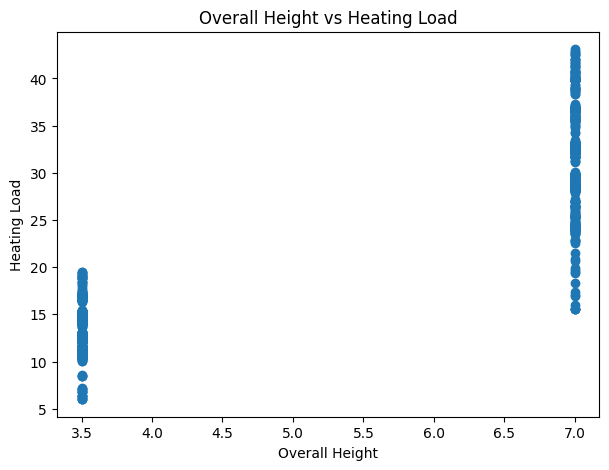

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(
    df["Overall_Height"],
    df["Heating_Load"]
)

plt.xlabel("Overall Height")
plt.ylabel("Heating Load")
plt.title("Overall Height vs Heating Load")

plt.show()

In [ ]:
correlation = df.corr()

correlation["Heating_Load"].sort_values(ascending=False)

,Heating_Load
Heating_Load,1.000000
Cooling_Load,0.975862
Overall_Height,0.889431
Relative_Compactness,0.622272
Wall_Area,0.455671
Glazing_Area,0.269841
Glazing_Area_Distribution,0.087368
Orientation,-0.002587
Surface_Area,-0.658120
Roof_Area,-0.861828


In [ ]:
# X：8 個輸入特徵
X_model = X

# y：只預測 Heating Load
y_model = y["Heating_Load"]

# 將資料切成 80% training、20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [ ]:
model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_lr = model_lr.predict(X_test)

print(y_pred_lr[:10])

[18.86296033 14.04938012 31.31560297 35.90050966 15.33519734 28.61874876
 25.02910328 28.08302126 17.75580683 27.59925541]


In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})

comparison.head(10)

,Actual,Predicted
0,16.47,18.862960
1,13.17,14.049380
2,32.82,31.315603
3,41.32,35.900510
4,16.69,15.335197
5,23.80,28.618749
6,24.31,25.029103
7,28.67,28.083021
8,19.52,17.755807
9,28.07,27.599255


In [ ]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

Linear Regression
MAE: 2.1820470221279207
RMSE: 3.025423582773618
R²: 0.912184095154691
